<h1 align="center" 
    style="color:#9B59FF; 
           font-family:Georgia; 
           font-style:italic; 
           font-size: 36px; 
           border-top: 5px solid #9B59FF; 
           border-bottom: 5px solid #9B59FF; 
           padding: 20px 0;
           margin: 30px auto;
           width: 90%;
           letter-spacing: 2px;">
SECTION ONE: FEATURE EXTRACTION & ENERGY-BASED CROSSFADE
</h1>

# 1. Define bibliotheques and imports

In [118]:

import numpy as np
import librosa
from scipy.ndimage import gaussian_filter
import soundfile as sf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity, pairwise_distances
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from dataclasses import dataclass

# 2.  Define Datacalss for extracted features and Beat tracking

In [119]:


@dataclass
class AudioFeatures:
    onset: np.ndarray
    rms: np.ndarray
    mfcc: np.ndarray
    flux: np.ndarray
    energy: np.ndarray

@dataclass
class BeatInfo:
    tempo: float
    beats: np.ndarray

# 3. Feature && Rhythm,Tempo Extraction 
- Onset strength measures how strongly and suddenly a new sound begins in music ---- onset
- RMS measures the energy (loudness) of the audio signal over time---->RMS
- MFCC extracts timbre (sound texture) features from audio over time----> Mfcc
- Tracks changes in the frequency content of sound ----> flux
- Align feature vectors to the same length  ----->  onset + RMS + flux 
- weighted feature fusion is used to estimate the energy of a beat or bar    
- Represents the impact of the combined weighted features over the timeline of the signal and i represent it as **Energy**
- onset(represent new musical event or new instrument) + RMS ( Root Mean Squere represents avarge amplitude over time) + flux(represents the change of the frequency over time  )
- estiamate tempo and tracking beat by using onset stringth anstead orginal signal because it makes beat detection easier and more accurat 


In [120]:
def extract_features(y, sr, hop_length=512):

    onset = librosa.onset.onset_strength(y=y, sr=sr, hop_length=hop_length)
    rms = librosa.feature.rms(y=y, hop_length=hop_length)[0]
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, hop_length=hop_length)
    
    S = np.abs(librosa.stft(y, hop_length=hop_length))
    flux = np.sqrt(np.sum(np.diff(S, axis=1)**2, axis=0))
    flux = np.pad(flux, (1, 0))
    
    min_len = min(len(onset), len(rms), len(flux))
    onset = onset[:min_len]
    rms = rms[:min_len]
    flux = flux[:min_len]
    energy = 0.4 * onset + 0.3 * rms + 0.3 * flux
    return AudioFeatures(onset = onset, rms=rms, mfcc = mfcc, flux = flux, energy = energy)

def extract_rhythm(features,sr,hop_length=512):
    tempo, beats = librosa.beat.beat_track(onset_envelope=features.onset, sr=sr, hop_length=hop_length)
    tempo = float(np.asarray(tempo).item())
    beats = np.asarray(beats, dtype=int)
    return BeatInfo(tempo=tempo, beats=beats)

# 4. Detect downbeats using beat tracking and the energy of each beat
- Call function "extract_feature" with hop length 512 not use dynamic hop length 
- Call fuction extract_rhythm"  
- Calculate the average feature between consecutive beats, then apply a Gaussian filter to reduce noise and obtain smooth peaks representing high-energy beats
- After that, we shift a window of 4 steps over the entire signal to find the strongest beat pattern, which represents the downbeat
- Based on the detected downbeats, the bars were extracted such that each bar starts at a consecutive downbeat. Similarly, musical phrases were segmented using a fixed length of 8 beats

In [121]:
def estimate_downbeats(y, sr):
    # Anfang fest hop_length
    hop_length = 512
    features = extract_features(y, sr, hop_length=hop_length)
    beat_info = extract_rhythm (features, sr, hop_length=hop_length)
    onset = features.onset
    score_f = features.energy
    beats = beat_info.beats
    beats_per_bar = 4
    beat_scores = []
    
    for i in range(len(beats)-1):
        s, e = beats[i], beats[i+1]
        if e <= s or e > len(onset): continue
        beat_slice = score_f[s:e]
        beat_scores.append(np.mean(beat_slice))
    energy = gaussian_filter(beat_scores, sigma=1)
    phase_scores = [np.mean(energy[shift::beats_per_bar]) for shift in range(beats_per_bar)]
    best_shift = np.argmax(phase_scores)
    downbeats = beats[best_shift::beats_per_bar]
    bars = [beats[(beats >= downbeats[i]) & (beats < downbeats[i+1])]
                  for i in range(len(downbeats)-1)]
    bars_per_phrase = 8
    phrase = downbeats[::bars_per_phrase] #asstimated phrase 
    #phrase = [beats[(beats >= downbeats[i]) &(beats < downbeats[i + bars_per_phrase])] for i in range(0, len(downbeats) - bars_per_phrase, bars_per_phrase)] # items of phrase
    return { "downbeats": downbeats, "bars": bars, "phrase": phrase}

# 5. Estimate the strongest bar, which i later use for transition detection
- based on bar energy. In the same way, estimate the strongest beat
- here, we take the mean value of each bar.

In [122]:
def compute_bar_energy(y, sr, bars_beats, hop_length=512):

    features = extract_features(y,sr,hop_length=hop_length)
    energy = features.energy
    bar_energy = []
    for bar in bars_beats:
        if len(bar) == 0:
            bar_energy.append(0)
            continue
        bar_mean = np.mean(energy[bar])
        bar_energy.append(bar_mean)
    bar_energy = np.array(bar_energy)
    bar_energy = (
        bar_energy - np.min(bar_energy)
    ) / (np.max(bar_energy) - np.min(bar_energy) + 1e-6)

    return bar_energy

# 6. Build a function to select the best pair of bars between songs, which is used later for crossfade
- initialize a default score 
- search about energy which happpens in the 40 % of the last of the songs and with the 60 % of the second song 
- ccompare the energy values of bars from the both songs 
- calculate the energy differeanc and select the pair with the smallest difference 
- If no valid pair is found, a fallback position is used (80% of the first song and 10% of the second) 

In [123]:
def find_best_transition(energy1, energy2):
    best_score = 999
    best_pair = (0, 0)
    
    start_i = int(len(energy1) * 0.6)
    end_j = int(len(energy2) * 0.4)

    for i in range(start_i, len(energy1)):
        for j in range(0, end_j):
            diff = abs(energy1[i] - energy2[j])
            if diff < best_score:
                best_score = diff
                best_pair = (i, j)
                
    if best_pair == (0, 0) and len(energy1) > 0 and len(energy2) > 0:
        best_pair = (int(len(energy1)*0.8), int(len(energy2)*0.1))
        
    return best_pair

# 7.  Crossfade transition function

- After calculating the energy and selecting the best pair of bars between songs, convert their indices to samples.
- Calculate the fade length based on the tempo and the number of bars (8 bars in this case).
- Get the fade zone for both song signals.
- Ensure that both fade zones have the same length to allow smooth mixing.
- Create fade-out and fade-in curves using cosine and sine functions.
- Mix the two fade zones by gradually decreasing the first song volume and increasing the second song volume.
- Concatenate the first song part, the mixed transition part, and the remaining part of the second song.
- Return the final audio signal with the crossfade transition.

In [124]:
def smart_crossfade(y1, y2, sr, t1_frame, t2_frame, tempo, hop_length, bars=8):
    # Da t1_frame und t2_frame bereits echte Librosa-Frames sind, 
    # rechnen wir sie mit ihrer jeweils korrekten Hop-Length in Samples um:
    t1_start = librosa.frames_to_samples(t1_frame, hop_length=hop_length)
    t2_start = librosa.frames_to_samples(t2_frame, hop_length=hop_length)
    
    sec_per_beat = 60.0 / tempo
    beat_length = sec_per_beat * sr
    fade_samples = int(beat_length * bars)
    
    y1_fade_zone = y1[t1_start : t1_start + fade_samples]
    y2_fade_zone = y2[t2_start : t2_start + fade_samples]
    
    min_len = min(len(y1_fade_zone), len(y2_fade_zone))
    if min_len == 0:
        return np.concatenate([y1[:t1_start], y2[t2_start:]])
        
    y1_fade_zone = y1_fade_zone[:min_len]
    y2_fade_zone = y2_fade_zone[:min_len]
   
    fade_out = np.cos(np.linspace(0, np.pi/2, min_len))
    fade_in  = np.sin(np.linspace(0, np.pi/2, min_len))
        
    mixed_part = (y1_fade_zone * fade_out) + (y2_fade_zone * fade_in)
    
    output = np.concatenate([
        y1[:t1_start],  
        mixed_part,     
        y2[t2_start + min_len:]
    ])
    return output

# 8. Main 

- Load the song files and apply the trim effect to remove silence.
- Call the feature extraction functions and calculate the features and tempo of the loaded songs.
- Call the estimate_downbeats function and get the correct downbeats and bars aligned with the downbeats.
- Calculate the tempo ratio between the songs and adjust the tempo of song 2 based on this ratio.
- Recalculate the downbeats and bars if song 2 has a different tempo from song 1.
- Compute the bar energy for both songs and compare them to find the best matching bars.
- Pass the selected bar indices to the crossfade function and convert them to samples in step 7.
- Extract and save the final matched song as an output file.

In [125]:
print("Starting and time-corrected DJ Mix..")
#  Define paths for the song files 
file1 = r"C:\Users\YAlkhafaji\Desktop\Automated_Dj\Electronic\Tranquilizer_spotdown.org.mp3"
file2 = r"C:\Users\YAlkhafaji\Desktop\Automated_Dj\Electronic\Gravity (feat. Laura Korinth) - Edit_spotdown.org.mp3"
output_path = r"C:\Users\YAlkhafaji\Desktop\Automated_Dj\DJ_Mix444_Final.wav"
 
# load files of songs with sample rate 44100
y1, sr = librosa.load(file1, sr=44100)
y2, _ = librosa.load(file2, sr=44100)
y1, _ = librosa.effects.trim(y1)
y2, _ = librosa.effects.trim(y2)

# compute tempo for both songs 
tempo = []
beats = []
for item in [y1, y2]:
    features = extract_features(item, sr, hop_length=512)
    beats_info = extract_rhythm(features, sr, hop_length=512)
    tempo.append(beats_info.tempo)
    beats.append(beats_info.beats)
tempo1, tempo2 = tempo
beats1 , beats2 = beats
# find DOwnbeats and Bars
downbeats1 = estimate_downbeats(y1, sr)
down1 = downbeats1["downbeats"]
bars1 = downbeats1["bars"]
phrase1= downbeats1["phrase"]

# adjast tempo song 2 based on the ratio 
rate = tempo1 / tempo2
y2_stretched = librosa.effects.time_stretch(y=y2, rate=rate)

# again compute Downbeats and Bras of adjusted song 2
downbeats2_new = estimate_downbeats(y2_stretched, sr)
down2_new = downbeats2_new["downbeats"]
bars2_new = downbeats2_new["bars"]

# compute bars energy
energy1 = compute_bar_energy(y1, sr, bars1, hop_length=512)
energy2 = compute_bar_energy(y2_stretched, sr, bars2_new, hop_length=512)


best_i, best_j = find_best_transition(energy1, energy2)
mix_frame_song1 = bars1[best_i][0]
mix_frame_song2 = bars2_new[best_j][0]

# compute Mixing time 
mix_sec = librosa.frames_to_time(mix_frame_song1, sr=sr, hop_length=512)
minutes = int(mix_sec // 60)
seconds = int(mix_sec % 60)
print(f"Actual mixing time of the first song in the player: {minutes}:{seconds:02d} ({mix_sec:.2f} Seconds)")

# Create the crossfade transition
final_mix = smart_crossfade( y1,y2_stretched,sr,mix_frame_song1,mix_frame_song2,tempo=tempo1,hop_length=512,bars=8)

# Extract and save the final matched song
sf.write(output_path, final_mix, sr)
print(f"Saved successfully: {output_path}")

Starting and time-corrected DJ Mix..
Actual mixing time of the first song in the player: 6:57 (417.16 Seconds)
Saved successfully: C:\Users\YAlkhafaji\Desktop\Automated_Dj\DJ_Mix444_Final.wav


<h1 align="center" 
    style="color:#9B59FF; 
           font-family:Georgia; 
           font-style:italic; 
           font-size:36px;
           border-top: 5px solid #9B59FF; 
           border-bottom: 5px solid #9B59FF; 
           padding: 20px 0;
           margin: 30px auto;
           width: 90%;
           letter-spacing: 2px;">
SECTION TWO: SEGMENTATION
</h1>

# 1. Generate Dynamic Hop_length Based on Tempo
- Compute the beat samples by multiplying the sampling rate (sr) with the beat duration in seconds
- Assume that the frame size is half of the beat samples
- Calculate the hop length as half of the frame size, which corresponds to one quarter of the beat samples

In [126]:
def get_hop_length(tempo,sr):
    beat_samples =int(sr *(60.0 / tempo))
    frame_size = beat_samples // 2
    hop_length = frame_size // 2
    return hop_length

# 2. Build a checkerboard kernel based on a Gaussian window

- Create a Gaussian kernel and convert it into a checkerboard pattern by changing the signs of two quadrants.
- Pad the input matrix to handle the borders.
- Slide the checkerboard kernel across the Self-Similarity Matrix to detect structural changes.
- Calculate the correlation between the kernel and each local region.
- Return the correlation values, which represent structural changes in the matrix.

In [127]:
import scipy.signal.windows
# ─────────────────────────────────────────────────────────────────────
# 1. Checkerboard
# ─────────────────────────────────────────────────────────────────────
def calculateCheckerboardCorrelation(matrix, N):
    M      = min(matrix.shape[0], matrix.shape[1])
    result = np.zeros(M)
    u      = scipy.signal.windows.gaussian(2*N, std=N/2.0).reshape(2*N, 1)
    U      = np.dot(u, u.T)
    U[:N, N:] *= -1
    U[N:, :N] *= -1
    matrix_padded = np.pad(matrix, N, mode='constant', constant_values=0)
    for i in range(N, N + M):
        sub = matrix_padded[i-N:i+N, i-N:i+N]
        result[i-N] = np.sum(sub * U)
    return result


# 3. Compute the Self-Similarity Matrix (SSM) using RMS and MFCC features to detect structural changes in the songs.
prepeare SSM from RMS and MFCC
- Call function **get_hop_length** and use dynamic hop_length which based on tempo  
- Extract MFCC features to capture the timbral characteristics of the audio
- Extract RMS energy to represent loudness variations over time
- Align all feature vectors to the same length to avoid dimensional mismatches
- Apply StandardScaler to normalize all features to zero mean and unit variance
- Standardization ensures that no single feature dominates the similarity calculation due to differences in scale.

Compute Self similarity Matrix 
- SSM_MFCC using cosine_similarity
- SSM_RMS  compute firstly distance each frame with other and then find SSM_RMS by applying difference maximal defference  distance 
- Apply a Gaussian filter to both Self-Similarity Matrices to reduce noise and obtain clearer peaks

Novelty Detection
- Apply a checkerboard kernel on each SSM to calculate novelty curves.
- Timbre novelty detects large structural changes (instrument/section changes).
- Energy novelty detects rhythmic and bass changes.
- Combine both novelty curves with equal weights to get one final novelty curve.

Adaptive Threshold and Peak Detection
- Convert the analysis window from seconds to frames based on hop_time
- Ensure that the window size is an odd number to correctly compute the local average around each frame
- Calculate the local mean of the final novelty curve using moving average convolution
- Create an adaptive threshold by adding a small offset to the local mean
- Define a minimum distance between detected peaks to avoid detecting multiple changes too close together
- Detect peaks in the novelty curve that exceed the adaptive threshold
- Convert detected peak positions from frame indices into time in seconds
- Create a time axis corresponding to the novelty curve frames
- Return detected transition points, novelty curve, time axis, and similarity features




In [128]:

def find_segmentation(y, sr, tempo):
# ─────────────────────────────────────────────────────────────────────
# 1. extract MFCC AND RMS
#──────────────────────────────────────────────────────────────────────────────────────────
    beat_samples = int(sr * (60.0 / tempo) / 2)
    hop_length   = beat_samples // 2
    hop_time     = hop_length / sr
    features = extract_features(y,sr,hop_length=hop_length)
    mfcc = features.mfcc.T
    rms  = features.rms.reshape(-1, 1)  
    min_len = min(len(mfcc), len(rms))
    mfcc, rms = mfcc[:min_len], rms[:min_len]
    mfcc = StandardScaler().fit_transform(mfcc)
    rms  = StandardScaler().fit_transform(rms)
# ─────────────────────────────────────────────────────────────────────
# 2. SSM Matrix
#──────────────────────────────────────────────────────────────────────
    ssm_mfcc   = cosine_similarity(mfcc)
    dist_rms   = pairwise_distances(rms)
    ssm_rms    = np.max(dist_rms) - dist_rms
    def smooth_normalize(ssm,sigma=None):
        if sigma is not  None:
            ssm=gaussian_filter(ssm,sigma=sigma)
        return (ssm - ssm.min()) / (ssm.max() - ssm.min() + 1e-6)
    ssm_mfcc = smooth_normalize(ssm_mfcc,sigma=1.0)
    ssm_rms  = smooth_normalize(ssm_rms,sigma=1.0)
# ─────────────────────────────────────────────────────────────────────
# 3. Novelty Detection (SSM  convolve with gaussian Kernal) and Combined them 
#──────────────────────────────────────────────────────────────────────
    N_mfcc= 32
    N_rms = 16
    nov_mfcc   = calculateCheckerboardCorrelation(ssm_mfcc,   N_mfcc)
    nov_rms    = calculateCheckerboardCorrelation(ssm_rms,    N_rms)

    # smooth and normlize the result for both novelty matrix (RMS AND MFCC)
    nov_mfcc   = smooth_normalize(nov_mfcc)
    nov_rms    = smooth_normalize(nov_rms)

    # Combine both novelty curves using equal weights
    combined = (0.5 * nov_mfcc + 0.5* nov_rms)
    combined = smooth_normalize(combined, sigma = 1.5)
# ─────────────────────────────────────────────────────────────────────
# 4. Adaptive Threshold and peak Detection
#─────────────────────────────────────────────────────────────────────
    window_frames = int(6.0 / hop_time) 
    if window_frames % 2 == 0:
        window_frames += 1
    local_mean = np.convolve(combined, np.ones(window_frames)/window_frames, mode='same')
    threshold  = local_mean + 0.005
    min_dist = int(5.0 / hop_time) 
    peaks, props = find_peaks(combined, height=threshold, distance=min_dist)
    raw_times = [p * hop_time for p in peaks]
    time_axis = np.arange(len(combined)) * hop_time

    return {
    "raw_times": np.array(raw_times),
    "combined": combined,
    "time_axis": time_axis,
    "peaks": peaks,
    "ssm_mfcc": ssm_mfcc,
    "nov_mfcc": nov_mfcc,
    "nov_rms": nov_rms,
    "hop_length": hop_length
}
# ─────────────────────────────────────────────────────────────────────
# 5. Call function to show the times of peaks 
# ─────────────────────────────────────────────────────────────────────

# ─────────────────────────────────────────────────────────────────────
# 6. Call the function and apply it to the first song's signal
# ─────────────────────────────────────────────────────────────────────
peaks_points = find_segmentation(y1, sr, tempo1)
peaks = peaks_points["peaks"]
raw_times = peaks_points["raw_times"]
combined = peaks_points ["combined"] 
print(f"\n Peaks frames:", peaks)

print(f"\n{'═'*70}")
print(f"  TECHNO RAW DETECTED CUE POINTS (BEFORE GRID ALIGNMENT)")
print(f" Track Tempo: {tempo1:.1f} BPM")
print(f"{'─'*70}")
print(f"  {'#':<4} {'Raw Seconds':<15} {'Exact Time (MM:SS)':<25} {'Novelty Amplitude'}")
print(f"{'─'*70}")
# 7. convert detected peaks to time 
for i, p_idx in enumerate(peaks):
    time_in_seconds = raw_times[i]
    minutes = int(time_in_seconds // 60)
    seconds = int(time_in_seconds % 60)
    peak_amplitude = combined[p_idx]
    time_str = f"{minutes:02d}:{seconds:02d}"
    
    print(f"  {i+1:<4} {time_in_seconds:<15.3f} {time_str:<25} {peak_amplitude:.4f}")

print(f"{'═'*70}\n")




 Peaks frames: [  78  129  196  242  348  406  452  517  584  672  743  829  899  949
 1001 1070 1152 1238 1301 1397 1484 1581 1636 1683 1728 1784 1861 1910
 1996 2071 2158 2237 2324 2399 2444 2582 2634 2701 2754 2823 2872 2993
 3066 3157 3238 3287 3356 3473 3582 3635]

══════════════════════════════════════════════════════════════════════
  TECHNO RAW DETECTED CUE POINTS (BEFORE GRID ALIGNMENT)
 Track Tempo: 126.0 BPM
──────────────────────────────────────────────────────────────────────
  #    Raw Seconds     Exact Time (MM:SS)        Novelty Amplitude
──────────────────────────────────────────────────────────────────────
  1    9.282           00:09                     0.0582
  2    15.351          00:15                     0.3292
  3    23.324          00:23                     0.1293
  4    28.799          00:28                     0.5480
  5    41.413          00:41                     0.3458
  6    48.315          00:48                     0.0851
  7    53.789          00:53   

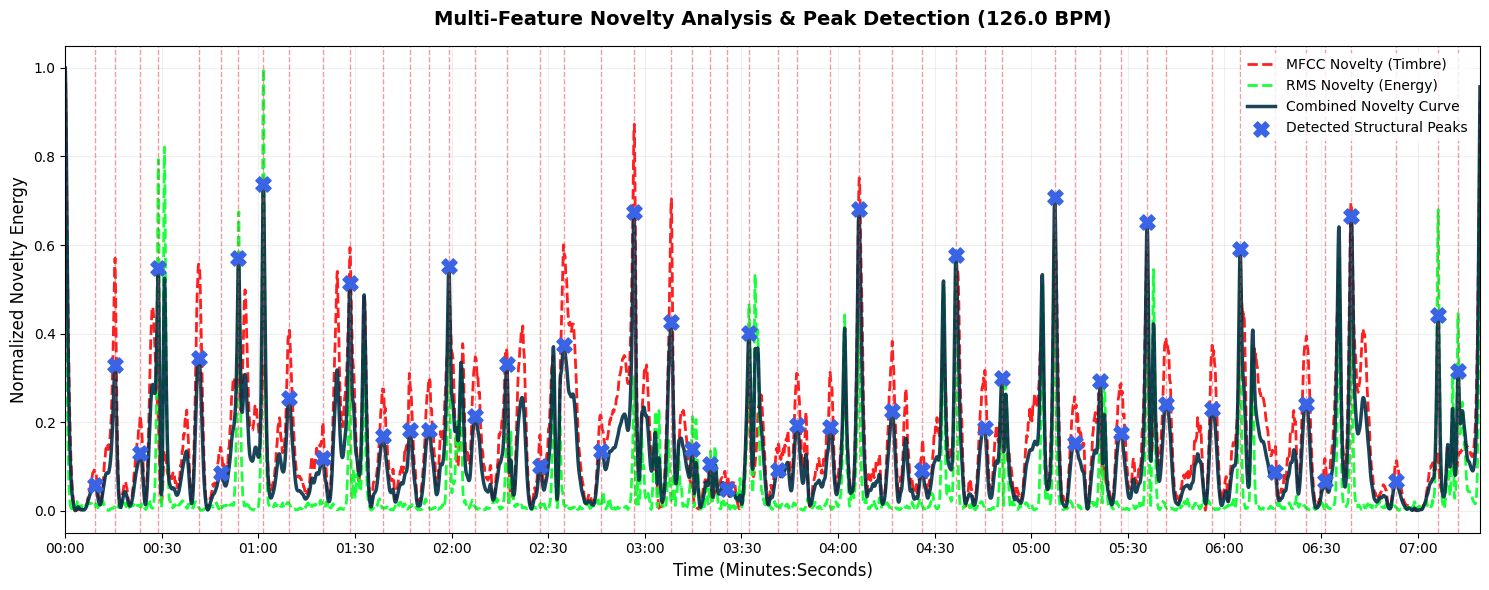

In [129]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def plot_novelty_analysis(peaks_points, tempo):

    time_axis = peaks_points["time_axis"]
    nov_mfcc = peaks_points["nov_mfcc"]
    nov_rms = peaks_points["nov_rms"]
    combined = peaks_points["combined"]
    peaks = peaks_points["peaks"]

    fig, ax = plt.subplots(figsize=(15, 6))
    ax.plot(time_axis, nov_mfcc, color="#ff0606", alpha=0.9, linestyle='--', linewidth=2.0, label='MFCC Novelty (Timbre)')
    ax.plot(time_axis, nov_rms, color="#00ff26", alpha=0.9, linestyle='--', linewidth=2.0, label='RMS Novelty (Energy)')
    ax.plot(time_axis, combined, color='#023047', alpha=0.9, linewidth=2.5, label='Combined Novelty Curve')
    ax.scatter(time_axis[peaks], combined[peaks], color="#3964e6", marker='X', s=120, zorder=5, label='Detected Structural Peaks')
    for p in peaks:
        ax.axvline(x=time_axis[p], color='#e63946', linestyle='--', alpha=0.5, linewidth=1)
    ax.set_title(f'Multi-Feature Novelty Analysis & Peak Detection ({tempo:.1f} BPM)', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Time (Minutes:Seconds)', fontsize=12)
    ax.set_ylabel('Normalized Novelty Energy', fontsize=12)
    ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
    ax.grid(True, linestyle='-', alpha=0.2)
    
    ax.set_xlim(0, time_axis[-1])
    def custom_time_format(x, pos):
        mins = int(x // 60)
        secs = int(x % 60)
        return f"{mins:02d}:{secs:02d}"
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(custom_time_format))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(30))

    plt.tight_layout()
    plt.show()
plot_novelty_analysis(peaks_points, tempo1)

# 4. Draw beats, downbeats, and detected peaks over time
- Pass all data in frame format and remap detected peaks using hop length 512
- Convert frames to time format using the sampling rate (sr)
- Build the plot object with a figure size of 14x6
- Draw vertical lines (vlines) for each of the three groups of points (beats, downbeats, peaks) across the X-axis
- Configure visual parameters for each group, including custom labels, colors, and line widths
- Overlay a scatter plot for detected peaks at the zero-amplitude line for clear visual targeting
- Set title, axis labels, limits (60 to 90 seconds), and a subtle grid to enhance readability
- At the End ,call the function and apply it to the first song's signal

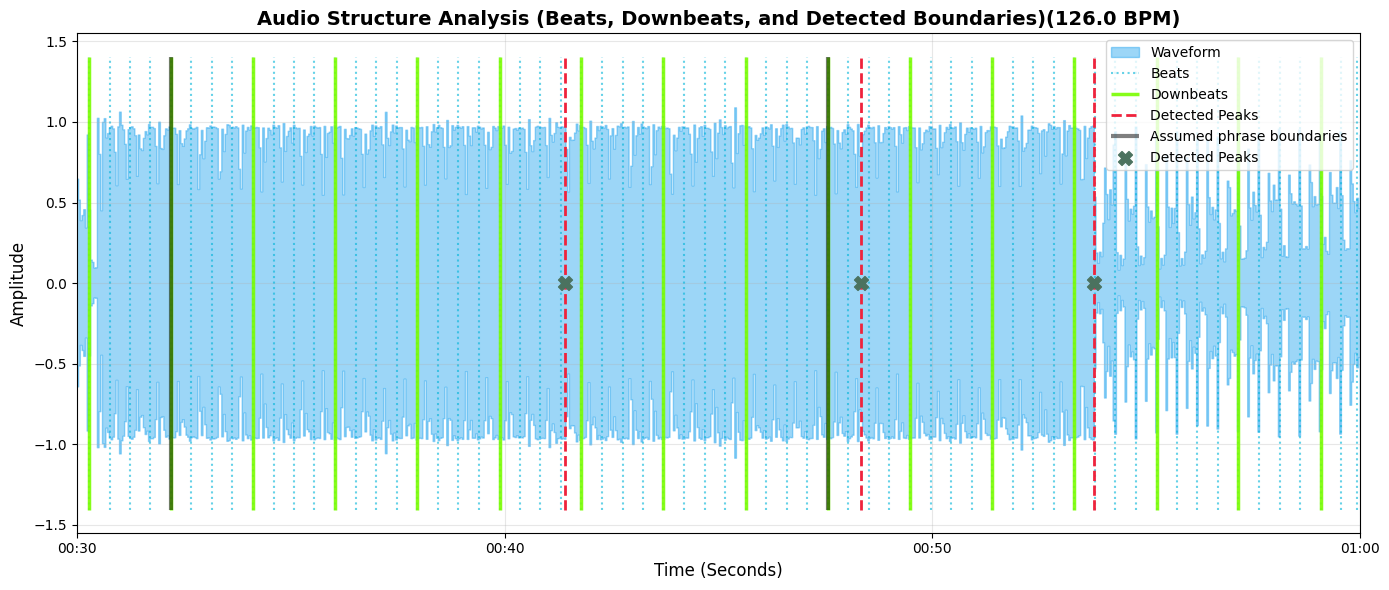

first 40 beats: [   3   44   86  127  168  210  251  292  334  375  416  458  499  540
  582  623  665  706  747  789  830  871  913  954  995 1037 1078 1119
 1161 1202 1243 1285 1326 1368 1409 1450 1491 1533 1574 1615]
first 10 daownbeats: [ 127  292  458  623  789  954 1119 1285 1450 1615]
first 3 assumed phrases [  127  1450  2773  4096  5399  6722  8045  9368 10691 12014 13328 14639
 15942 17265 18588 19911 21233 22557 23879 25202 26525 27848 29171 30494
 31817 33140 34451 35765]
 length of peaks: 50


In [130]:

import matplotlib.pyplot as plt
import numpy as np
import librosa
import librosa.display
import matplotlib.ticker as ticker

def plot_peaks_with_peaks(y, beats, downbeats,phrase, peaks, sr, tempo, dhop_length):
    hop_length_fixed = 512
    
# ─────────────────────────────────────────────────────────────────────
#  Prepare all points (DOWNBEATS, BEATS, PEAKS) and convert them into time
# ─────────────────────────────────────────────────────────────────────
    peaks_frames = np.round(peaks * (dhop_length / hop_length_fixed)).astype(int)
    peaks_times = librosa.frames_to_time(peaks_frames, sr=sr, hop_length=hop_length_fixed)
    beat_times = librosa.frames_to_time(beats, sr=sr, hop_length=hop_length_fixed)
    downbeats_times = librosa.frames_to_time(downbeats, sr=sr, hop_length=hop_length_fixed)
    phrase_timees = librosa.frames_to_time(phrase, sr=sr, hop_length = hop_length_fixed)
# ─────────────────────────────────────────────────────────────────────
# Build the plot object and draw  vertical lines for all points
# ─────────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 6))
    librosa.display.waveshow(y, sr=sr, ax=ax, color="#0999ec", alpha=0.4, label='Waveform')
    ax.vlines(beat_times, ymin=y.min(), ymax=y.max(), color='#00b4d8', linestyle=':', alpha=0.6, label='Beats')
    ax.vlines(downbeats_times, ymin=y.min(), ymax=y.max(), color="#7afd00", linestyle='-', linewidth=2.5, alpha=0.9, label='Downbeats')
    ax.vlines(peaks_times, ymin=y.min(), ymax=y.max(), color='#ef233c', linestyle='--', linewidth=2, alpha=1.0, label='Detected Peaks')
    ax.vlines(phrase_timees,ymin = y.min(),ymax=y.max(),color="#000000", linestyle="-",linewidth=3,alpha=0.50,label="Assumed phrase boundaries")
    ax.scatter(peaks_times, np.zeros_like(peaks_times), color="#4b725f", marker='X', s=100, zorder=5, label='Detected Peaks')
# ─────────────────────────────────────────────────────────────────────
# label both axis X AND Y and 
# ─────────────────────────────────────────────────────────────────────
    ax.set_title(f'Audio Structure Analysis (Beats, Downbeats, and Detected Boundaries)({tempo:.1f} BPM)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Time (Seconds)', fontsize=12)
    ax.set_ylabel('Amplitude', fontsize=12)
    ax.legend(loc='upper right', frameon=True)
    ax.grid(True, linestyle='-', alpha=0.3)
#  time slice from 60 to 90 seconds We can change it manually wwhen we want zoom in ,zoom out
    ax.set_xlim(30, 60) 
    def custom_time_format(x, pos):
        mins = int(x // 60)
        secs = int(x % 60)
        return f"{mins:02d}:{secs:02d}"
    
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(custom_time_format))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
    
    plt.tight_layout()
    plt.show()

# ─────────────────────────────────────────────────────────────────────
# Call the function and apply it to the first song's signal
# ─────────────────────────────────────────────────────────────────────
plot_peaks_with_peaks(y1, beats1, down1, phrase1, peaks, sr, tempo1, get_hop_length(tempo1, sr))
print(f"first 40 beats:", beats1[:40])
print(f"first 10 daownbeats:", down1[:10])
print(f"first 3 assumed phrases",phrase1)
print (f" length of peaks:", len(peaks))




# 5. Boundries anlignment 
- Pass the detected boundaries, the combined novelty curve, aligned bars, tempo, dynamic hop length, sample rate, and total duration 
- Compute the hop time based on the fixed hop length (512 samples)
- Calculate the duration of each bar in seconds based on the detected tempo 
- Convert the detected bar positions from frame indices into time seconds
- Re-map the detected peak indices from the dynamic hop length representation to the fixed hop length (512 samples) to unify the time resolution
- we calculate the timestamp ($t_{peak}$) for each peak. By finding the bar timestamp ($time\_bars$) closest to $t_{peak}$ (minimizing the absolute difference), we obtain the nearest bar index.
- Next, we keep only the peaks that are within half of the bar duration 


In [138]:
def boundries_anlignment(peaks, combined_curve, bar_aligned, tempo, hop_length, sr, total_dur):

    if len(bar_aligned) == 0 or len(peaks) == 0:
        return np.array([0.0, total_dur])
    hop_length_fixed = 512
    hop_time = hop_length_fixed / sr
    bar_duration_seconds = 4 * (60.0 / tempo)
# ─────────────────────────────────────────────────────────────────────
# Scale peak indices from the original hop_length to the fixed 512 hop_length grid and convert bar positions to absolute time
# ─────────────────────────────────────────────────────────────────────
    time_bars = bar_aligned * hop_time 
    peaks_in_512 = np.round(peaks * (hop_length / hop_length_fixed)).astype(int)
    peaks_pos = np.sort(peaks_in_512)
    peaks_ampl = combined_curve[peaks]
    
    peaks_db_indices = []
    peaks_weights = []
    for p_idx, pos in enumerate(peaks_pos):
        t_peak = pos * hop_time
        db_index = np.argmin(np.abs(time_bars - t_peak))
#  ─────────────────────────────────────────────────────────────────────       
# filter only the peaks within half of the bar duration 
#  ─────────────────────────────────────────────────────────────────────
        if abs(time_bars[db_index] - t_peak) <= (0.75 * bar_duration_seconds):
            peaks_db_indices.append(db_index)
            peaks_weights.append(peaks_ampl[p_idx])
    peaks_db_indices = np.array(peaks_db_indices)
    peaks_weights = np.array(peaks_weights)
# ─────────────────────────────────────────────────────────────────────
# 8-Bar Structural Pattern Filter and determine the winning grid phase  
# ─────────────────────────────────────────────────────────────────────

    phase_scores = np.zeros(8)
    for phase in range(8):
        score = 0.0
        for db_idx, weight in zip(peaks_db_indices, peaks_weights):
            if (db_idx - phase) % 8 == 0:
                score += weight
        phase_scores[phase] = score
    winner_phase = np.argmax(phase_scores) 
# ─────────────────────────────────────────────────────────────────────
# grid phase voting system (identify winning rhythmic pattern)
# ─────────────────────────────────────────────────────────────────────
    aligned_indices = []
    for db_idx in peaks_db_indices:
        if (db_idx - winner_phase) % 8 == 0:
            aligned_indices.append(db_idx)
        
    last_downbeat_idx = len(bar_aligned) - 1
    aligned_indices.append(winner_phase)
    aligned_indices.append(last_downbeat_idx - ((last_downbeat_idx - winner_phase) % 8))
    
    aligned_indices = np.unique(sorted(aligned_indices))
    aligned_indices = np.clip(aligned_indices, 0, last_downbeat_idx)
    structural_boundaries = time_bars[aligned_indices]
# ─────────────────────────────────────────────────────────────────────
# filter phase 2: magnetic grid snapping & duration constraint (>= 8 bars)
# ─────────────────────────────────────────────────────────────────────
    final_bounds = [0.0]
    for t in structural_boundaries:
        if t <= 0.0:
            continue
        
        diff_seconds = t - final_bounds[-1]
        num_bars_float = diff_seconds / bar_duration_seconds
        num_bars_rounded = int(np.round(num_bars_float / 8.0) * 8)
        if num_bars_rounded >= 8:
            t_snapped = final_bounds[-1] + (num_bars_rounded * bar_duration_seconds)
            if t_snapped <= time_bars[-1]:
                final_bounds.append(t_snapped)

    diff_end = total_dur - final_bounds[-1]
    end_bars_float = diff_end / bar_duration_seconds
    
    if diff_end > (1.0 * bar_duration_seconds): 
        final_bounds.append(total_dur)
    else:
        final_bounds[-1] = total_dur
        
    return np.array(sorted(list(set(final_bounds))))

# Plot the detected boundaries aligned with the winning 8-bar structural pattern and show the phrase boundaries with the number of bars contained in each Segment.

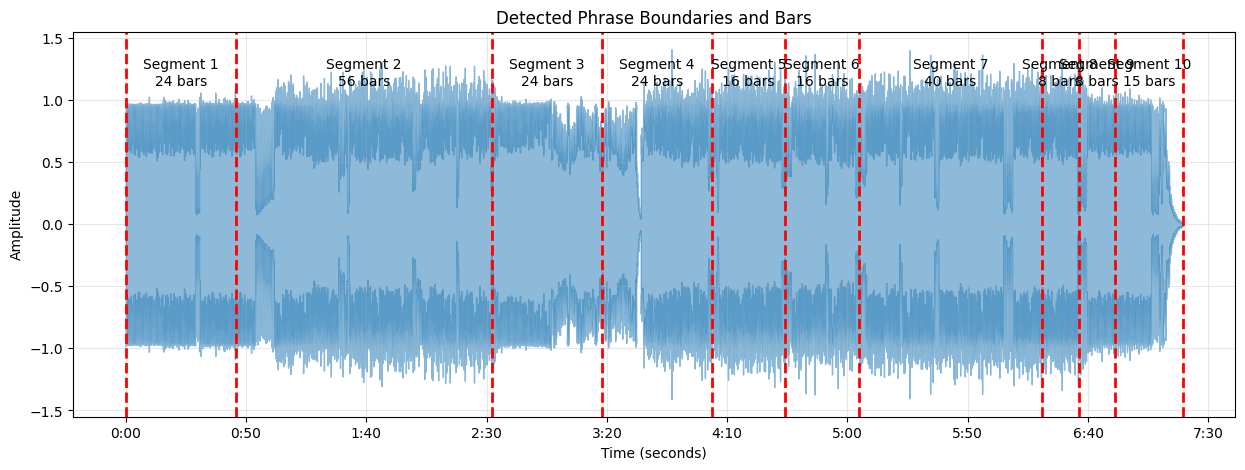

In [139]:
def plot_phrases_and_bars(y, sr, boundaries, tempo):

    bar_duration = 4 * (60 / tempo)
    fig, ax = plt.subplots(figsize=(15,5))
    librosa.display.waveshow(y, sr=sr, ax=ax, alpha=0.5)
    
    for i, b in enumerate(boundaries):
        ax.axvline(b, color="red",linestyle="--",linewidth=2)
        if i < len(boundaries)-1:

            duration = boundaries[i+1] - boundaries[i]
            bars = round(duration / bar_duration)
            center = boundaries[i] + duration/2

            ax.text(center,y.max()*0.8,f"Segment {i+1}\n{bars} bars",ha="center",fontsize=10)

    ax.set_title("Detected Phrase Boundaries and Bars")
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Amplitude")

    plt.grid(alpha=0.3)
    plt.show()

# Use existing notebook variables: 'combined' and 'down1' (not undefined names)
bounds = boundries_anlignment(
    peaks=peaks,
    combined_curve=combined,
    bar_aligned=down1,
    tempo=tempo1,
    hop_length=get_hop_length(tempo1, sr),
    sr=sr,
    total_dur=len(y1)/sr
)

plot_phrases_and_bars(y1,sr,bounds,tempo1)